In [3]:
import psutil
import platform
import os
env_name = os.environ.get('CONDA_DEFAULT_ENV')
print("当前 conda 环境名：", env_name)
print(platform.system()) # 操作系统名称
print(platform.release()) # 操作系统版本
print(platform.machine()) # 计算机架构
print(platform.processor()) # 处理器类型
# CPU 信息
print(psutil.cpu_count()) # CPU 核数
print(psutil.cpu_freq()) # CPU 频率
# 内存信息
print(psutil.virtual_memory()) # 内存总量、可用内存、已用内存等

当前 conda 环境名： dl_env
Windows
10
AMD64
Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
16
scpufreq(current=1900.0, min=0.0, max=1900.0)
svmem(total=16794320896, available=1689391104, percent=89.9, used=15104929792, free=1689391104)


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
def xyplot(x_vals, y_vals, name):
    plt.figure(figsize=(5, 2.5))
    plt.plot(x_vals.detach().numpy(), y_vals.detach().numpy())
    plt.xlabel('x')
    plt.ylabel(name + '(x)')
    plt.show()

# 多层感知机
## 理论计算

1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输入为x，隐藏层没有激活函数（即线性激活），表达为h=W1x+b1，输出层为o=W2h+b2 。请通过代数推导证明，该网络等价于一个单层神经网络，并写出等价后的权重矩阵W′和偏置向量b′。

输出 $O \in \mathbb{R}^{n \times q}$ 的计算为：
$$
H = XW_h + b_h,
$$
$$
O = HW_o + b_o,
$$
代入得
$$
O = (XW_1 + b_1)W_2 + b_2 = X(W_1W_2) + (b_1W_2 + b_2)
$$
因此，等价后的权重矩阵为 $W' = W_1W_2$，偏置向量为 $b' = b_1W_2 + b_2$。

2. 激活函数性质分析：写出Sigmoid(x) 和 tanh(x) 的数学表达式，并推导它们的导数Sigmoid′(x) 和 tanh′(x) 与其函数自身的关系。

sigmoid函数可以将元素的值变换到0和1之间：
$$sigmoid(x) = \frac{1}{1+e^{-x}} = \frac{e^{x}}{e^{x}+1}$$

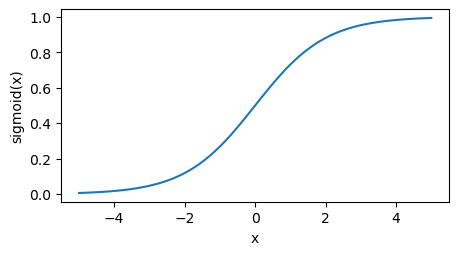

In [34]:
x = torch.linspace(-5, 5, 100, requires_grad=True)
y = torch.sigmoid(x)
xyplot(x, y, 'sigmoid')

根据链式法则，sigmoid函数的导数可以表示为：
$$sigmoid'\,(x) = sigmoid(x) (1 - sigmoid(x)).$$

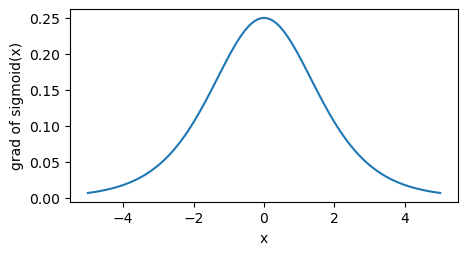

In [35]:
y.sum().backward()
xyplot(x, x.grad, 'grad of sigmoid')

tanh（双曲正切）函数可以将元素的值变换到-1和1之间：
$$\tanh(x) = \frac{1 - e^{-2x}}{1 + e^{-2x}} = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$$
实际上，tanh函数是sigmoid函数的一个线性变换：$\tan h(x) = 2 \mathrm{sigmoid}(2x) - 1$

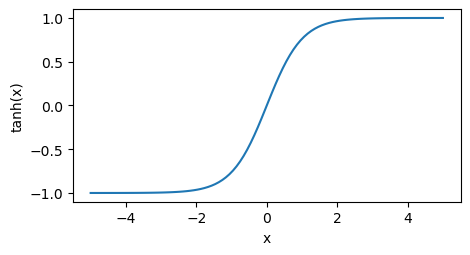

In [36]:
y = x.tanh()
xyplot(x, y, 'tanh')

依据链式法则，tanh函数的导数为：
$$\tanh'(x) = 1 - \tanh^2(x)$$

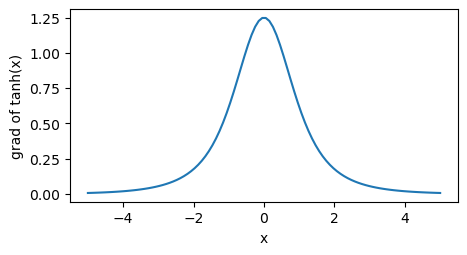

In [37]:
y.sum().backward()
xyplot(x, x.grad, 'grad of tanh')

## 编程题
不使用深度学习框架的高级API（仅使用Tensor基础算子如torch.matmul等），纯 NumPy 或 PyTorch 从零实现一个多分类（使用 Fashion-MNIST数据集）的单隐藏层MLP。实现要求：
1. 手动初始化隐藏层参数W1,b1 和输出层参数W2,b2（提示：使用正态分布随机初始化）
2. 实现 ReLU 激活函数的前向传播：max(0,x) 。
3. 实现带有Softmax 的交叉熵损失函数。
4. 编写训练循环，通过小批量随机梯度下降（Mini-batch SGD）手动更新参数。

In [2]:
# 1. 加载数据
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
batch_size = 256
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

In [3]:
# 2. 初始化参数
input_size = 784
hidden_size = 256
output_size = 10

W1 = torch.randn(input_size, hidden_size)
W1 *= 0.01
W1.requires_grad_()
b1 = torch.zeros(hidden_size, requires_grad=True)
W2 = torch.randn(hidden_size, output_size)
W2 *= 0.01
W2.requires_grad_()
b2 = torch.zeros(output_size, requires_grad=True)

In [4]:
# 3. ReLU
def relu(x):
    return x.clamp(min=0.0)

# 4. Softmax交叉熵损失（手动实现，注意数值稳定）
def cross_entropy_with_softmax(logits, y):
    # logits: (batch, num_classes), y: (batch,) 真实标签索引
    exp_logits = torch.exp(logits - logits.max(dim=1, keepdim=True)[0])  # 稳定化
    probs = exp_logits / exp_logits.sum(dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    return loss


In [5]:
lr = 0.1
epochs = 10

for epoch in range(epochs):
    for X, y in train_loader:
        # 前向
        h = relu(torch.matmul(X, W1) + b1)
        logits = torch.matmul(h, W2) + b2
        loss = cross_entropy_with_softmax(logits, y)

        # 反向
        loss.backward()   

        # 手动更新参数
        with torch.no_grad():
            W1.data -= lr * W1.grad
            b1.data -= lr * b1.grad
            W2.data -= lr * W2.grad
            b2.data -= lr * b2.grad

            # 清零梯度
            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()
    
    # 打印每个 epoch 的损失
    print(f"Epoch {epoch+1}, loss: {loss.item():.4f}")

Epoch 1, loss: 0.5650
Epoch 2, loss: 0.6156
Epoch 3, loss: 0.4237
Epoch 4, loss: 0.5162
Epoch 5, loss: 0.4216
Epoch 6, loss: 0.3655
Epoch 7, loss: 0.3623
Epoch 8, loss: 0.3960
Epoch 9, loss: 0.3728
Epoch 10, loss: 0.3281


# 模型选择，权重衰减和丢弃法
## 理论计算题
1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Generalization Error）的区别。当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这一现象？   

**训练误差**（training error）：模型在训练数据集上计算得到的误差。  
**泛化误差**（generalization error）：模型应用在同样从原始样本的分布中抽取的无限多数据样本时，模型误差的期望。 
当模型训练误差极低，但泛化误差很高时，称为**过拟合**。缓解过拟合的核心是**降低模型复杂度**，主要通过以下三类方法：  

(1) **参数约束（正则化）**：  
- **L1 / L2 正则化**：在损失函数中加入权重的范数惩罚项（L1范数或L2范数），限制权重的大小或稀疏性，从而降低模型复杂度。
- **权重衰减**：等价于L2正则化，在SGD更新时令权重乘以(1 - ηλ)，直接抑制权重增长。

(2) **模型结构简化**：  
- **减少网络层数或神经元数量**：直接降低模型容量。
- **参数初始化**：虽然不能直接降低复杂度，但适当的小值初始化（如正态分布乘以较小标准差）可以避免初始权重过大导致的过拟合风险；不当的初始化反而可能加剧过拟合。通常将其视为训练技巧而非复杂度控制的主要手段。

(3) **干扰优化过程（随机化正则化）**：  
- **丢弃法（Dropout）**：训练时随机丢弃部分神经元，迫使网络学习冗余表示，相当于隐式集成，提升泛化性。
- **早停（Early Stopping）**：监控验证集性能，当验证误差不再下降时提前终止训练，防止模型过度拟合训练噪声。
- **数据增强**：通过对输入施加随机变换（旋转、裁剪、加噪等），增加有效训练样本量，降低对原始数据的过拟合。


2. K 折交叉验证：阐述K 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤   

在k折交叉验证中，我们把原始训练数据集分割成k个不重合的子数据集，然后我们做k次模型训练和验证。每一次，我们使用一个子数据集验证模型，并使用其他k−1个子数据集来训练模型。在这k次训练和验证中，每次用来验证模型的子数据集都不同。最后，我们对这k次训练误差和验证误差分别求平均。

## 编程题
在你实现的MLP上，加入L2 正则化和Dropout机制。
实现要求：
1. 权重衰减：在你的自定义SGD优化器中，加入权重衰减。即在计算梯度更新时，让旧权重首先乘以(1−ηλ)。
2. Dropout 从零实现：编写一个dropout_layer(X, dropout) 函数。根据传入的概率，利用随机掩码（Mask）将输入张量某些元素置0，并进行缩放。注意：通过一个布尔变量（如is_training）来控制测试时不触发Dropout 。
3. 对比实验：设计高维多项式拟合或使用极少样本训练一个复杂的MLP，绘制并对比：1) 无正则化、2) 有权重衰减、3) 有 Dropout 三种情况下的训练和验证误差曲线（LossCurve）

In [6]:
# 1.权重衰减（L2正则化）的SGD实现
def sgd(params, lr, weight_decay):
    """手动 SGD + 权重衰减"""
    with torch.no_grad():
        for param in params:
            if param.grad is None:
                continue
            # 权重衰减：W = W - η * λ * W
            if weight_decay > 0 and param.dim() >= 2:  # 通常只对权重衰减，不对偏置
                param.data -= lr * weight_decay * param.data
            # 标准梯度下降
            param.data -= lr * param.grad
            param.grad.zero_()

In [7]:
# 2. Dropout 从零实现
def dropout_layer(X, dropout, is_training=True):
    """Dropout 前向传播，测试时关闭"""
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    # 缩放：保证期望不变
    return mask * X / (1.0 - dropout)

In [11]:
dropout_rate = 0.5

# 在MLP的前向传播中使用
def net(X, is_training=True):
    X = X.reshape(-1, input_size)
    H = relu(torch.matmul(X, W1) + b1)
    if is_training and dropout_rate > 0:
        H = dropout_layer(H, dropout_rate)

    out = torch.matmul(H, W2) + b2    
    return out

In [12]:
# 3. 对比实验设置
# 取很少的训练样本
small_train_set = torch.utils.data.Subset(train_set, range(500))
small_train_loader = torch.utils.data.DataLoader(small_train_set, batch_size=64, shuffle=True)
def train_with_regularization(train_loader, test_loader, weight_decay, dropout_rate, epochs=50, lr=0.1):
    # 初始化参数（同上）
    W1 = torch.randn(784, 256)
    W1 *= 0.01
    W1.requires_grad_()
    b1 = torch.zeros(256, requires_grad=True)
    W2 = torch.randn(256, 10)
    W2 *= 0.01
    W2.requires_grad_()
    b2 = torch.zeros(10, requires_grad=True)
    params = [W1, b1, W2, b2]
    
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        # 训练阶段
        total_loss, total = 0, 0
        for X, y in train_loader:
            h = relu(torch.matmul(X, W1) + b1)
            if dropout_rate > 0:
                h = dropout_layer(h, dropout_rate, is_training=True)
            logits = torch.matmul(h, W2) + b2
            loss = cross_entropy_with_softmax(logits, y)
            loss.backward()
            sgd(params, lr, weight_decay)
            total_loss += loss.item() * X.shape[0]
            total += X.shape[0]
        train_losses.append(total_loss / total)
        
        # 验证阶段（不启用 Dropout，无梯度）
        with torch.no_grad():
            val_loss, val_total = 0, 0
            for X, y in test_loader:
                h = relu(torch.matmul(X, W1) + b1)
                # 测试时 dropout 关闭
                if dropout_rate > 0:
                    h = dropout_layer(h, dropout_rate, is_training=False)
                logits = torch.matmul(h, W2) + b2
                loss = cross_entropy_with_softmax(logits, y)
                val_loss += loss.item() * X.shape[0]
                val_total += X.shape[0]
            test_losses.append(val_loss / val_total)
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}: train loss {train_losses[-1]:.4f}, test loss {test_losses[-1]:.4f}")
    return train_losses, test_losses

Epoch 10: train loss 1.0148, test loss 0.9951
Epoch 20: train loss 0.6542, test loss 0.7983
Epoch 30: train loss 0.5025, test loss 0.7394
Epoch 40: train loss 0.3692, test loss 0.7196
Epoch 50: train loss 0.3077, test loss 0.7274
Epoch 60: train loss 0.2205, test loss 0.6748
Epoch 10: train loss 1.0602, test loss 1.0357
Epoch 20: train loss 0.6856, test loss 0.8506
Epoch 30: train loss 0.5248, test loss 0.7826
Epoch 40: train loss 0.4409, test loss 0.7070
Epoch 50: train loss 0.3533, test loss 0.6909
Epoch 60: train loss 0.2870, test loss 0.6542
Epoch 10: train loss 1.0912, test loss 1.0761
Epoch 20: train loss 0.7546, test loss 0.8329
Epoch 30: train loss 0.5728, test loss 0.7105
Epoch 40: train loss 0.4963, test loss 0.6766
Epoch 50: train loss 0.3536, test loss 0.6546
Epoch 60: train loss 0.3359, test loss 0.6547


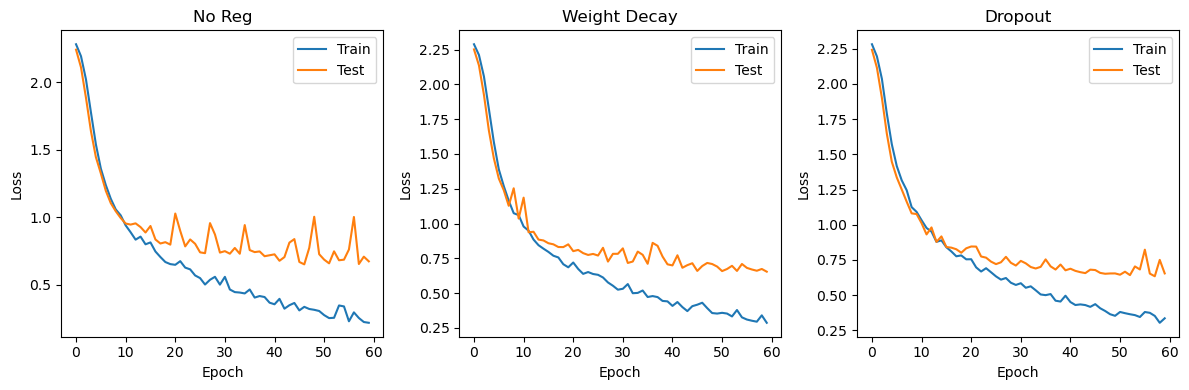

In [13]:
# 绘图对比
configs = [
    ("No Reg", 0.0, 0.0),
    ("Weight Decay", 0.01, 0.0),
    ("Dropout", 0.0, 0.5)
]

plt.figure(figsize=(12,4))
for i, (name, wd, dp) in enumerate(configs):
    train_loss, test_loss = train_with_regularization(small_train_loader, test_loader, wd, dp, epochs=60)
    plt.subplot(1,3,i+1)
    plt.plot(train_loss, label='Train')
    plt.plot(test_loss, label='Test')
    plt.title(name)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

# 数值稳定性和激活函数
## 理论计算题
梯度消失与梯度爆炸：考虑一个d层的深层神经网络，其梯度计算包含诸如多层矩阵连乘项$\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}}$
1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯度爆炸，什么情况下会导致梯度消失。  

考虑一个 d 层的深层神经网络，反向传播时第 t 层的梯度包含如下的矩阵连乘项：$$\frac{\partial L}{\partial h^{t}} = \frac{\partial L}{\partial h^{d}} \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}}$$  
其中每一层的 Jacobian 矩阵为：$$\frac{\partial h^{i+1}}{\partial h^{i}} = \mathrm{diag}(\sigma'(z^i)) \cdot (W^i)^T$$
这里 $W^i$ 是第 $i$ 层的权重矩阵, $z^i$ 是第 $i$ 层的输入, $\sigma'$ 是激活函数的导数, $T$ 是转置矩阵。     

**梯度爆炸的条件：**
当连乘项中每个 Jacobian 矩阵的谱半径（最大特征值绝对值）大于 1 时，随着层数 d−t 增加，梯度的范数会指数增长。典型情形：   
- 激活函数在大部分区域的导数 ≥ 1（例如 ReLU 的正半轴导数为 1）   
- 权重矩阵的奇异值大于 1，且网络层数深   
- 具体量化:若$\forall i, \|W^{i}\|_{2}^{2} > 1 \land \sigma'(z) \ge 1, \quad \Big\| \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}} \Big\|_{2} \ge \prod_{i=t}^{d-1} \|W^{i}\|_{2} \rightarrow \infty \quad \text{当 } d \rightarrow \infty$    

**梯度消失的条件：**
当每个 Jacobian 矩阵的谱半径 < 1 时，连乘结果指数衰减至 0。典型情形：  
- 激活函数导数最大值小于 1，如 Sigmoid：$\sigma'(x) = \sigma(x)(1-\sigma(x)) \leq 0.25$ ，tanh：$\sigma'(x) = 1 - \tanh^2(x) \leq 1$  
- 权重矩阵的奇异值小于 1，或初始化权重过小，且网络层数深  
- 具体量化:若$\forall i, \|W^{i}\|_{2}^{2} < 1 \land \sigma'(z) < 1, \quad \Big\| \prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^{i}} \Big\|_{2} \leq \prod_{i=t}^{d-1} \|W^{i}\|_{2} \rightarrow 0 \quad \text{当 } d \rightarrow \infty$    
因此，梯度爆炸和消失的根本原因在于每层 Jacobian矩阵的谱半径是否大于或小于 1，以及网络的深度。


2. 为什么改用ReLU 激活函数可以很大程度上缓解梯度消失问题？  
如果激活函数的导数为1，那么就不会出现梯度消失的问题。ReLU 激活函数在正半轴的导数恒为1，这意味着在正半轴区域内，梯度不会因为激活函数的导数而衰减，从而大大缓解了梯度消失问题。

##  编程题
模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。
实现要求：
1. 构建深层网络：使用 PyTorch 的高级 API (nn.Sequential) 构建一个20 层的深层全连接网络，隐藏层宽度设为256。
2. 模拟梯度消失/爆炸：全部激活函数采用Sigmoid，权重采用普通高斯分布初始化（如nn.init.normal_(m.weight, mean=0, std=1)），输入随机数据，观察并打印前几层和后几层的梯度范数（GradientNorm），验证梯度消失。
3. 激活函数采用ReLU，权重采用较大的初值（如std=10），观察是否发生NaN（梯度爆炸或数值溢出）。
4. 修复与验证：使用Xavier 初始化（nn.init.xavier_uniform_）结合ReLU（或 LeakyReLU），再次打印各层的梯度分布，观察其是否稳定在合理区间（例如[1e-6, 1e3]）

In [2]:
import torch.nn as nn
import torch.nn.init as init

# 1.构建20层全连接网络
def build_deep_net(layers=20, width=256, activation='sigmoid', use_bias=True):
    """构建指定层数和激活函数的深层网络"""
    layers_list = []
    for i in range(layers):
        layers_list.append(nn.Linear(width, width, bias=use_bias))
        if activation == 'sigmoid':
            layers_list.append(nn.Sigmoid())
        elif activation == 'relu':
            layers_list.append(nn.ReLU())
        elif activation == 'leaky_relu':
            layers_list.append(nn.LeakyReLU(0.2))
        else:
            raise ValueError("Unsupported activation")
    return nn.Sequential(*layers_list)

In [3]:
# 2. 辅助函数：计算并打印每层的梯度范数
def register_gradient_hooks(model):
    """为每一层 Linear 注册 hook，保存其权重的梯度范数"""
    grad_norms = {}

    def hook_fn(name):
        def hook(grad):
            # grad 是权重的梯度张量，形状为 (out_features, in_features)
            grad_norms[name] = grad.norm().item()
        return hook

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            module.register_full_backward_hook(hook_fn(name))
    return grad_norms

In [ ]:
# 3. 辅助函数：计算并打印每层的梯度范数
def register_gradient_hooks(model):
    """为每一层 Linear 注册 hook，保存其权重的梯度范数"""
    grad_norms = {}

    def make_hook(name):
        def hook(grad):
            grad_norms[name] = grad.norm().item()
        return hook

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            module.weight.register_hook(make_hook(name))
    return grad_norms


In [5]:
# 4. 模拟梯度爆炸
def simulate_gradient_explosion():
    print("\n" + "="*50)
    print("模拟梯度爆炸: ReLU + N(0,10) 初始化")
    model = build_deep_net(activation='relu')
    def init_large(m):
        if isinstance(m, nn.Linear):
            init.normal_(m.weight, mean=0, std=10)
            if m.bias is not None:
                init.zeros_(m.bias)
    model.apply(init_large)
    
    x = torch.randn(4, 256)
    try:
        out = model(x)
        loss = out.sum()
        loss.backward()
        print("未出现 NaN，但梯度可能极大。检查参数：")
        for name, param in model.named_parameters():
            if torch.isnan(param).any():
                print(f"  {name} 包含 NaN")
            else:
                print(f"  {name} 范数: {param.norm().item():.6e}")
    except Exception as e:
        print(f"前向或反向传播出现异常: {e}")

In [6]:
# 修复：Xavier 初始化 + ReLU 激活
def simulate_xavier_initialization(activation='relu'):
    print("\n" + "="*50)
    print(f"Xavier初始化 + {activation.upper()}")
    model = build_deep_net(activation=activation)
    def init_xavier(m):
        if isinstance(m, nn.Linear):
            init.xavier_uniform_(m.weight)  # 均匀分布，方差 2/(in+out)
            if m.bias is not None:
                init.zeros_(m.bias)
    model.apply(init_xavier)
    
    grad_norms = register_gradient_hooks(model)
    x = torch.randn(4, 256)
    out = model(x)
    loss = out.sum()
    loss.backward()
    
    # 打印所有层的梯度范数（或统计）
    norms = list(grad_norms.values())
    print(f"梯度范数范围: min={min(norms):.6e}, max={max(norms):.6e}")
    print(f"所有层梯度范数: {[f'{v:.2e}' for v in norms]}")
    
    # 检查是否稳定在合理区间 [1e-6, 1e3]
    stable = all(1e-6 <= v <= 1e3 for v in norms)
    print(f"梯度稳定在合理区间: {stable}")

In [7]:
if __name__ == "__main__":
    simulate_gradient_vanishing()
    simulate_gradient_explosion()
    simulate_xavier_initialization('relu')
    simulate_xavier_initialization('leaky_relu')

模拟梯度消失: Sigmoid + N(0,1) 初始化


TypeError: register_gradient_hooks.<locals>.hook_fn.<locals>.hook() takes 1 positional argument but 3 were given

# 泛化表现，协变量偏移和对抗性数据
## 理论计算题
请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系： 
1. 协变量偏移(Covariate Shift)：表现为 $ p(x) \neq q(x)但 p(y|x) = q(y|x) $。
2. 标签偏移(Label Shift)：表现为 $ p(y) \neq q(y) 但 p(x|y) = q(x|y) $。


**区别:**  
**协变量偏移**：输入分布 $p(\mathbf{x})$ 改变，但条件分布 $p(y|\mathbf{x})$ 不变。  
例子：血液检测癌症。训练集中健康人的血液样本来自年轻学生，测试集中健康人来自老年男性。  
   - 输入 $\mathbf{x}$（血液指标）的分布因年龄、性别改变 → $p(\mathbf{x})$ 变化。  
   - 假设对于同一个血液指标值，患癌的概率与年龄性别无关 → $p(y|\mathbf{x})$ 不变。  
   属于协变量偏移。    

**标签偏移**：输出分布 $p(y)$ 改变，但条件分布 $p(\mathbf{x}|y)$ 不变。  
例子：根据症状预测疾病。训练集与测试集的疾病流行率不同（如流感季节患病率升高），但同一疾病引起的症状分布稳定。  
- $p(y)$ 变化（流行率变化）。  
- 给定疾病 $y$，症状 $\mathbf{x}$ 的分布相同 → $p(\mathbf{x}|y)$ 不变。  
    属于标签偏移。

**联系:**
1. **同属分布偏移**：训练集与测试集的联合分布 $p(\mathbf{x},y)$ 不同，但分别假设了不同的不变性。  
2. **都可使用重要性加权校正**：  
   - 协变量偏移：权重 $w(\mathbf{x}) = \frac{p_{\text{test}}(\mathbf{x})}{p_{\text{train}}(\mathbf{x})}$。  
   - 标签偏移：权重 $w(y) = \frac{p_{\text{test}}(y)}{p_{\text{train}}(y)}$。  
3. **可以同时发生**：例如疾病诊断中，既有人口年龄结构变化（$p(\mathbf{x})$ 变化），又有疾病流行率变化（$p(y)$ 变化），且 $p(y|\mathbf{x})$ 和 $p(\mathbf{x}|y)$ 都可能不完全不变。此时需更复杂的领域自适应方法。  
4. **依赖因果方向**：若 $y \to \mathbf{x}$（标签产生特征），标签偏移更合理；若 $\mathbf{x} \to y$（特征决定标签），协变量偏移更合理。

## 编程题
动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测性能。
实现要求：
1. 人工数据集构造：训练集P：从正态分布N(−1,1)中采样1000个特征x，标签y=2x+ϵ（ϵ为小噪声）。
2. 测试集 Q：从正态分布N(2,1) 中采样 500 个特征 x（此时发生了明显的协变量偏移）。
3. 基线模型：用一个简单的线性回归模型直接在训练集P 上训练，并在测试集Q上评估，记录均方误差（MSE）。
4. 偏移校正实现：编写一个逻辑回归分类器，将训练集P 的样本标记为类别0，测试集Q的样本标记为类别1。
(a) 将两组数据混合训练分类器，从而预测出每个样本属于测试集的概率P(test|x) 。
(b) 根据公式计算每个训练样本的权重$w_i \propto \frac{P(test|x_i)}{P(train|x_i)}$ 。
5. 加权模型训练：使用这些权重重新训练线性回归模型（加权最小二乘法），并再次在测试集Q上评估。对比校正前后的测试MSE，验证校正效果。

In [ ]:
# 1.人工数据集构造
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

# 训练集
n_train = 1000
x_train = np.random.normal(-1, 1, n_train).reshape(-1, 1)
y_train = 2 * x_train.ravel() + np.random.normal(0, 0.1, n_train)

# 测试集
n_test = 500
x_test = np.random.normal(2, 1, n_test).reshape(-1, 1)
y_test = 2 * x_test.ravel() + np.random.normal(0, 0.1, n_test)

In [ ]:
# 2. 线性回归模型训练
base_model = LinearRegression()
base_model.fit(x_train, y_train)
y_pred_base = base_model.predict(x_test)
mse_base = mean_squared_error(y_test, y_pred_base)
print(f"Baseline MSE on test: {mse_base:.4f}")

In [ ]:
# 3. 偏移矫正：训练逻辑回归估计密度比
# 混合数据并标记
x_mix = np.vstack([x_train, x_test])
y_mix = np.array([0] * n_train + [1] * n_test)   # 0:训练集, 1:测试集

# 训练逻辑回归
lr_disc = LogisticRegression()
lr_disc.fit(x_mix, y_mix)

# 得到每个训练样本属于测试集的概率
prob_test = lr_disc.predict_proba(x_train)[:, 1]   # P(test|x)
# 计算权重: P(test|x) / P(train|x)
weights = prob_test / (1 - prob_test + 1e-8)       # 避免除零错误

In [ ]:
# 4. 加权线性回归模型训练
weighted_model = LinearRegression()
weighted_model.fit(x_train, y_train, sample_weight=weights)
y_pred_weighted = weighted_model.predict(x_test)
mse_weighted = mean_squared_error(y_test, y_pred_weighted)
print(f"Weighted model MSE on test: {mse_weighted:.4f}")
print(f"Improvement: {mse_base - mse_weighted:.4f} ({100*(mse_base - mse_weighted)/mse_base:.1f}%)")

In [ ]:
if __name__ == "__main__":
    print(f"Baseline MSE: {mse_base:.4f}")
    print(f"Weighted MSE: {mse_weighted:.4f}")

In [ ]:
# 可视化
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(x_train, bins=30, alpha=0.5, label='Train')
plt.hist(x_test, bins=30, alpha=0.5, label='Test')
plt.xlabel('x'); plt.legend(); plt.title('Feature Distribution')

plt.subplot(1,3,2)
plt.scatter(x_train, y_train, s=1, label='Train')
plt.scatter(x_test, y_test, s=1, label='Test')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('Data')

plt.subplot(1,3,3)
plt.plot(prob_test, weights, 'o', markersize=2)
plt.xlabel('P(test|x)'); plt.ylabel('Weight'); plt.title('Importance Weights')
plt.tight_layout()
plt.show()